In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Importing of Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as py
%matplotlib inline
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Loading of Dataset**

In [2]:
htsong=pd.read_csv('/kaggle/input/hit-song/complete.csv')

**Data Info**

In [3]:
htsong.info()
htsong.columns
htsong.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34740 entries, 0 to 34739
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_title       34739 non-null  object 
 1   artist_name       34739 non-null  object 
 2   track_id          34740 non-null  object 
 3   duration_ms       34740 non-null  int64  
 4   energy            34740 non-null  float64
 5   key               34740 non-null  int64  
 6   mode              34740 non-null  int64  
 7   time_signature    34740 non-null  int64  
 8   acousticness      34740 non-null  float64
 9   danceability      34740 non-null  float64
 10  instrumentalness  34740 non-null  float64
 11  liveness          34740 non-null  float64
 12  loudness          34740 non-null  float64
 13  speechiness       34740 non-null  float64
 14  valence           34740 non-null  float64
 15  tempo             34740 non-null  float64
 16  On_chart          34740 non-null  int64 

,track_title,artist_name,track_id,duration_ms,energy,key,mode,time_signature,acousticness,danceability,instrumentalness,liveness,loudness,speechiness,valence,tempo,On_chart
0,Red Planet - Red Planet Radio,Joe,3FeufAV1f6fajILIQuAXMw,256080,0.96800,7,0,4,0.02150,0.698,0.862000,0.1110,-11.012,0.0337,0.3900,136.884,0
1,Red Planet - Red Planet Extended,Joe,2o7oYjZuo3S2QitY4R5dII,395442,0.97000,2,1,4,0.00339,0.724,0.896000,0.1060,-8.415,0.0358,0.4320,136.868,0
2,Basejump,Robin Schulz,6nWoNNkfffbmHU9z3kGPao,391680,0.40600,5,0,4,0.00433,0.803,0.825000,0.0948,-9.444,0.0608,0.0769,125.014,0
3,"Goldberg Variations, BWV 988 (Arr. for Accordi...",Johann Sebastian Bach,5Zg1UOcmee5oiRw3gbXna0,347840,0.00267,7,0,5,0.91000,0.150,0.028700,0.1250,-24.701,0.0434,0.1050,135.652,0
4,"Goldberg Variations, BWV 988 (Arr. for Accordi...",Johann Sebastian Bach,2ZWmWGoZS2OTGZSnMhck7Q,181733,0.22600,7,1,4,0.76800,0.290,0.000002,0.1050,-14.990,0.0385,0.4700,98.348,0


**Record Counts based on On_chart**

In [ ]:
htsong.On_chart.value_counts()

**Data Cleaning**

In [ ]:
htsong.isnull().sum()

In [5]:
htsong['track_title']=htsong['track_title'].fillna('').replace('',' ')
htsong['artist_name']=htsong['artist_name'].fillna('').replace('',' ')
htsong.isnull().sum()

track_title         0
artist_name         0
track_id            0
duration_ms         0
energy              0
key                 0
mode                0
time_signature      0
acousticness        0
danceability        0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
valence             0
tempo               0
On_chart            0
dtype: int64

In [6]:
htsong.drop('track_id',axis=1,inplace=True)
htsong.head(0)


,track_title,artist_name,duration_ms,energy,key,mode,time_signature,acousticness,danceability,instrumentalness,liveness,loudness,speechiness,valence,tempo,On_chart


**Checking Duplicates**

In [10]:
print(f"Duplicate rows is {htsong.duplicated()}")

Duplicate rows is 0        False
1        False
2        False
3        False
4        False
         ...  
34735    False
34736    False
34737    False
34738    False
34739    False
Length: 34740, dtype: bool


**Checking Correlation**

/tmp/ipykernel_33/3976754848.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correl = htsong.corr()


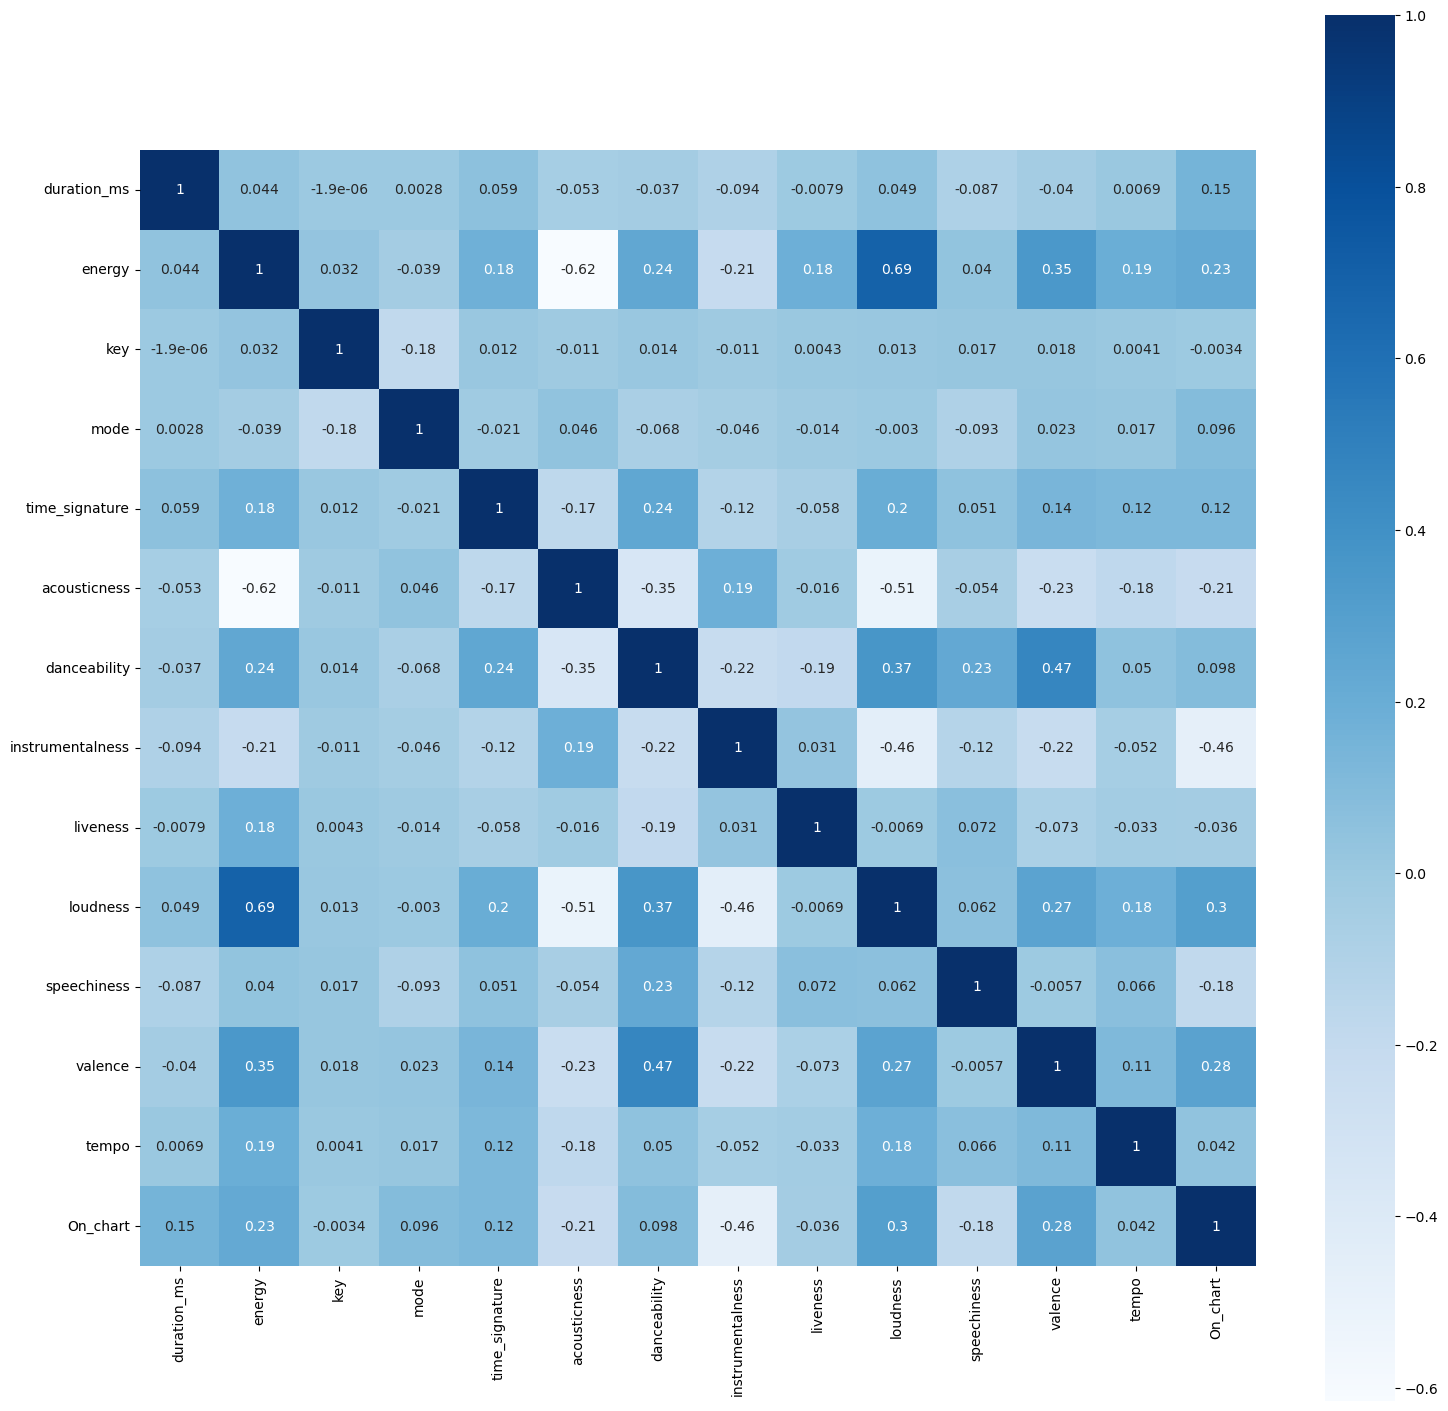

In [8]:
correl = htsong.corr()
py.figure(figsize=(18,18))
sns.heatmap(correl, annot=True, square=True, cmap='Blues')
py.show()

**Distinct values for each feature**

In [11]:
htsong.nunique().sort_values()

mode                    2
On_chart                2
time_signature          5
key                    12
danceability         1027
speechiness          1403
liveness             1659
valence              1671
energy               1805
acousticness         3856
instrumentalness     4898
artist_name         10768
loudness            14982
duration_ms         23745
tempo               24853
track_title         29996
dtype: int64

**Checking the dependency of variables having categorical values**

<Axes: xlabel='On_chart', ylabel='count'>

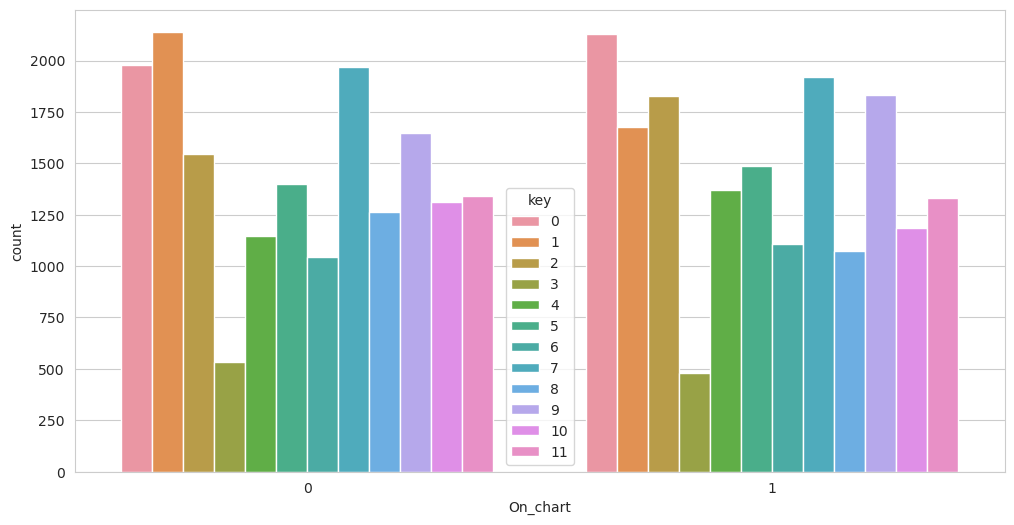

In [12]:
py.figure(figsize = (12,6))
sns.set_style("whitegrid")
sns.countplot(x="On_chart", hue="key", data=htsong)

<Axes: xlabel='On_chart', ylabel='count'>

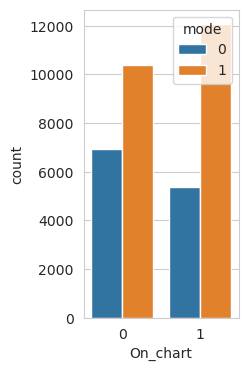

In [13]:
py.figure(figsize = (2,4))
sns.set_style("whitegrid")
sns.countplot(x="On_chart", hue="mode", data=htsong)

<Axes: xlabel='On_chart', ylabel='count'>

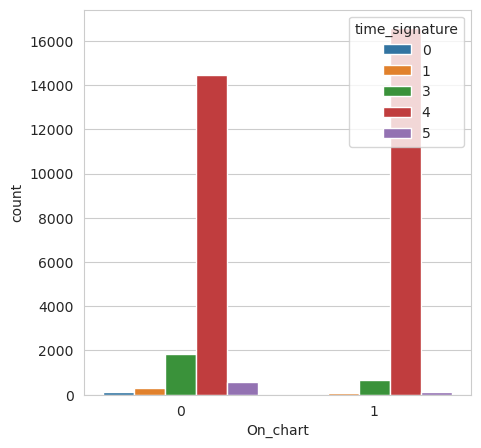

In [14]:
py.figure(figsize = (5,5))
sns.set_style("whitegrid")
sns.countplot(x="On_chart", hue="time_signature", data=htsong)

**Checking the dependency of variables having continous values**

<Axes: xlabel='On_chart', ylabel='energy'>

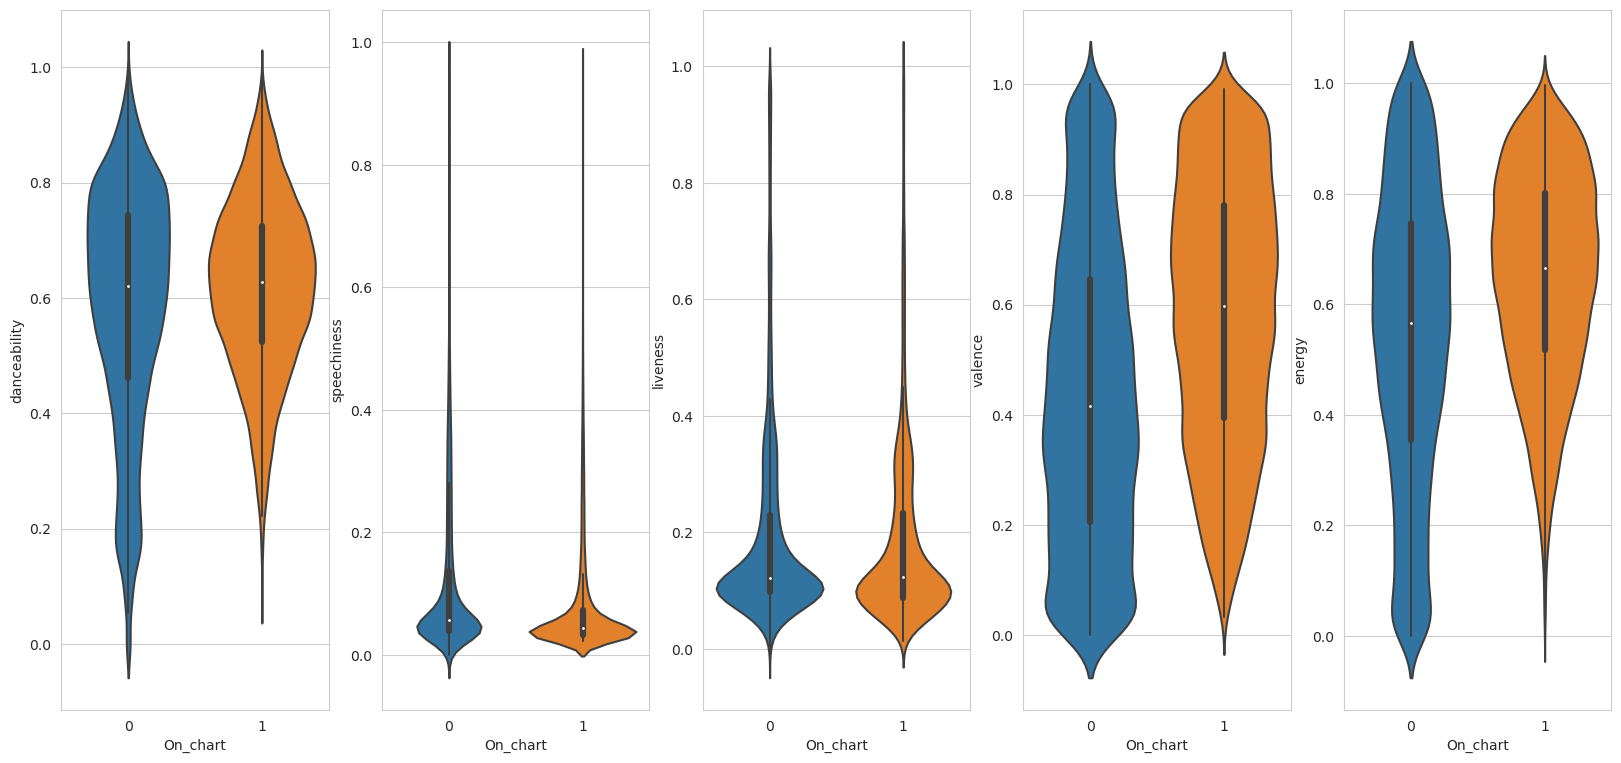

In [15]:
dep_plot1= py.figure(figsize=(20,20))
ax1= dep_plot1.add_subplot(2,5,1)
ax2= dep_plot1.add_subplot(2,5,2)
ax3= dep_plot1.add_subplot(2,5,3)
ax4= dep_plot1.add_subplot(2,5,4)
ax5= dep_plot1.add_subplot(2,5,5)

sns.violinplot(data=htsong, x= 'On_chart',y= 'danceability', ax=ax1)
sns.violinplot(data=htsong, x='On_chart', y= 'speechiness', ax=ax2)
sns.violinplot(data=htsong, x='On_chart', y= 'liveness', ax=ax3)
sns.violinplot(data=htsong, x= 'On_chart',y= 'valence', ax=ax4)
sns.violinplot(data=htsong, x='On_chart', y= 'energy', ax=ax5)

<Axes: xlabel='On_chart', ylabel='tempo'>

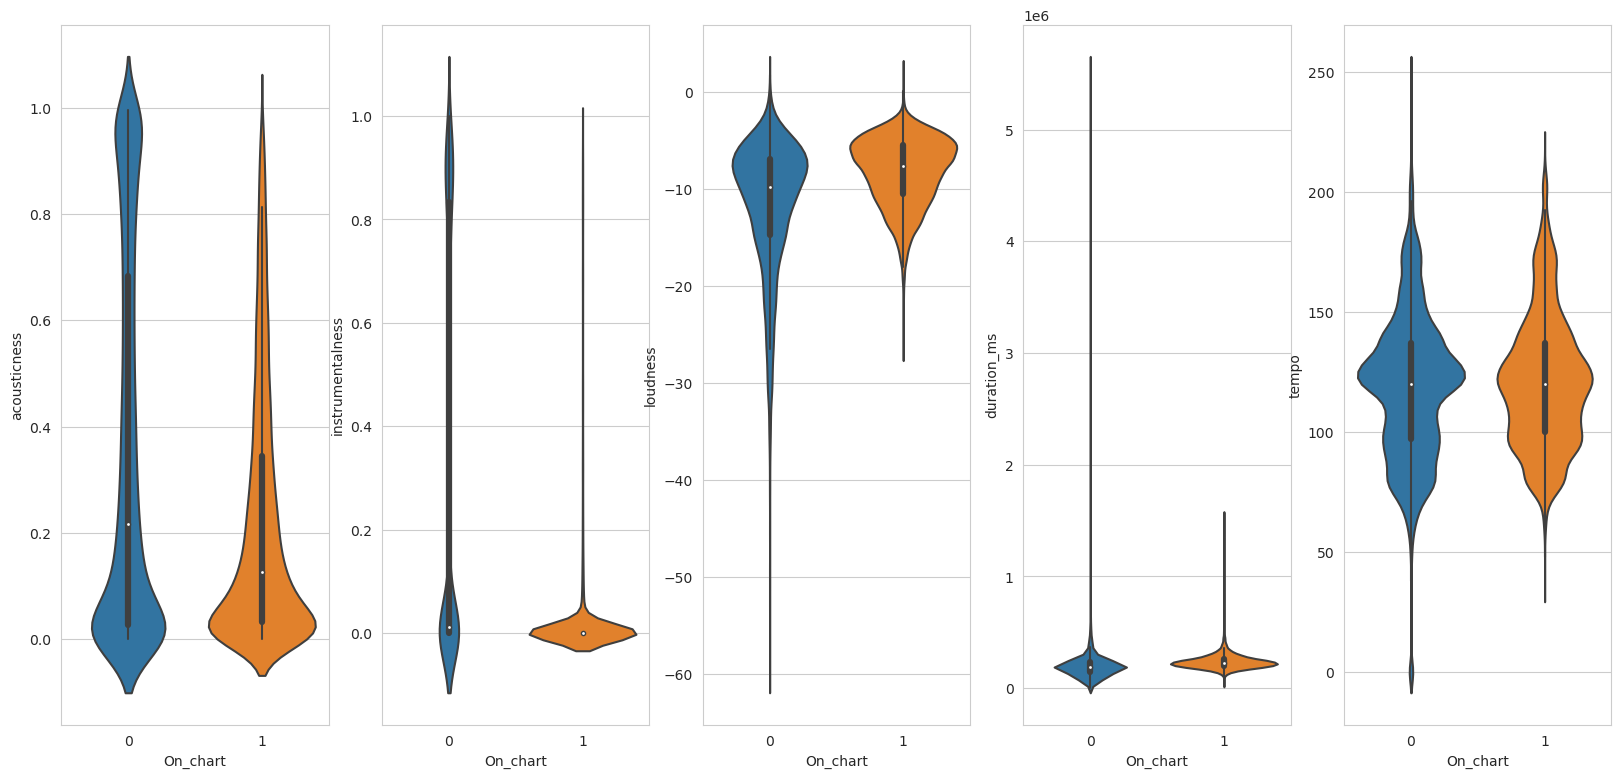

In [16]:
dep_plot2= py.figure(figsize=(20,20))
ax1= dep_plot2.add_subplot(2,5,1)
ax2= dep_plot2.add_subplot(2,5,2)
ax3= dep_plot2.add_subplot(2,5,3)
ax4= dep_plot2.add_subplot(2,5,4)
ax5= dep_plot2.add_subplot(2,5,5)

sns.violinplot(data=htsong, x='On_chart', y= 'acousticness', ax=ax1)
sns.violinplot(data=htsong, x='On_chart', y= 'instrumentalness', ax=ax2)
sns.violinplot(data=htsong, x='On_chart', y= 'loudness', ax=ax3)
sns.violinplot(data=htsong, x='On_chart', y= 'duration_ms', ax=ax4)
sns.violinplot(data=htsong, x='On_chart', y= 'tempo', ax=ax5)


**Checking whether each variables follows a normal distribution**

<Axes: xlabel='liveness', ylabel='Count'>

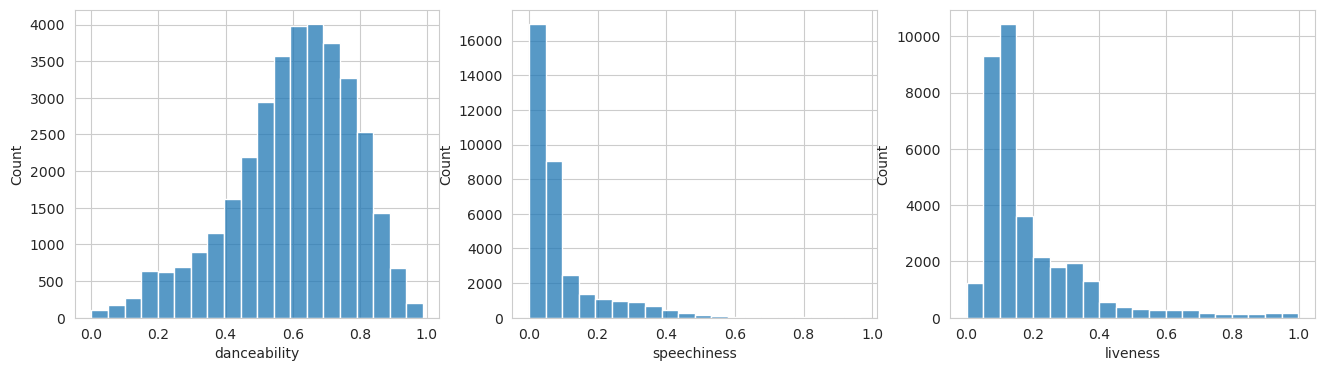

In [17]:
normal_dist1= py.figure(figsize=(16,4))
ax1= normal_dist1.add_subplot(1,3,1)
ax2= normal_dist1.add_subplot(1,3,2)
ax3= normal_dist1.add_subplot(1,3,3)

sns.histplot(htsong['danceability'], bins=20, ax=ax1)
sns.histplot(htsong['speechiness'], bins=20, ax=ax2)
sns.histplot(htsong['liveness'], bins=20, ax=ax3)

<Axes: xlabel='acousticness', ylabel='Count'>

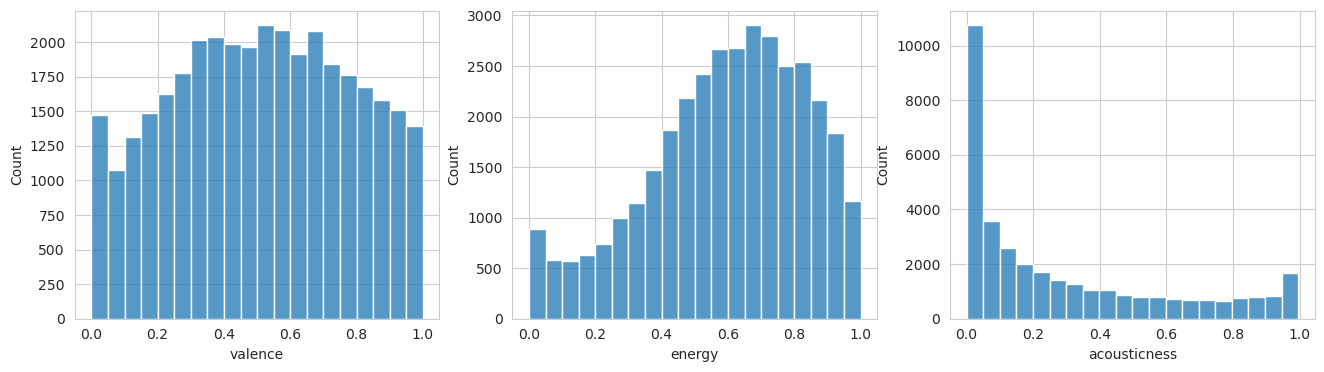

In [18]:
normal_dist2= py.figure(figsize=(16,4))
ax1= normal_dist2.add_subplot(1,3,1)
ax2= normal_dist2.add_subplot(1,3,2)
ax3= normal_dist2.add_subplot(1,3,3)

sns.histplot(htsong['valence'], bins=20, ax=ax1)
sns.histplot(htsong['energy'], bins=20, ax=ax2)
sns.histplot(htsong['acousticness'], bins=20, ax=ax3)

<Axes: xlabel='tempo', ylabel='Count'>

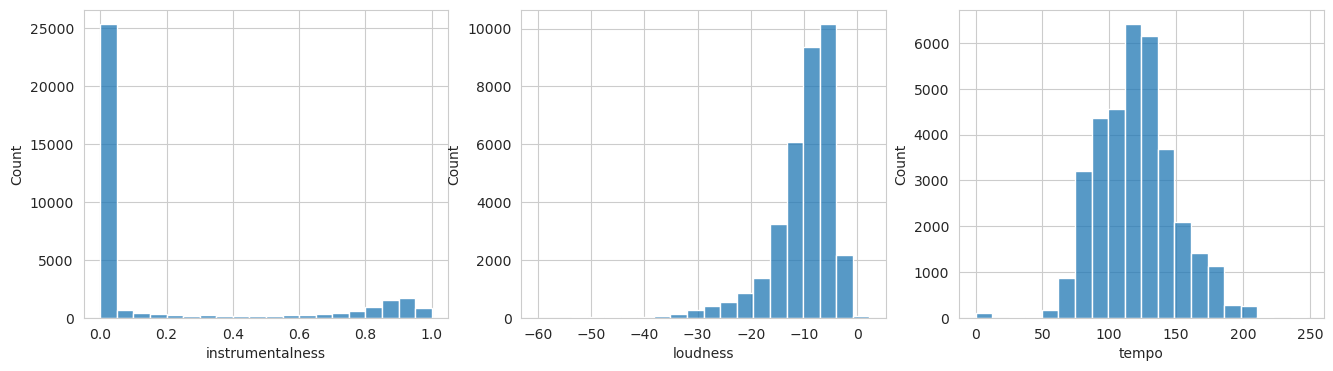

In [19]:
normal_dist3= py.figure(figsize=(16,4))
ax1= normal_dist3.add_subplot(1,3,1)
ax2= normal_dist3.add_subplot(1,3,2)
ax3= normal_dist3.add_subplot(1,3,3)

sns.histplot(htsong['instrumentalness'], bins=20, ax=ax1)
sns.histplot(htsong['loudness'], bins=20, ax=ax2)
sns.histplot(htsong['tempo'], bins=20, ax=ax3)

**Splitting Data**

In [20]:
from sklearn.model_selection import train_test_split
featre = htsong.drop(['On_chart','track_title','artist_name'], axis=1)
targ = htsong['On_chart']
X_train, X_test, Y_train, Y_test = train_test_split(featre,targ, test_size=0.2, random_state=42)


**Random Forest Classifier Model**

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
rand_model = RandomForestClassifier()
rand_model.fit(X_train,Y_train)
# Predicting Hit Song For Test Data
y_pred = rand_model.predict(X_test)
rand_test_acc = round(accuracy_score(Y_test, y_pred)*100,2)
print(f"Testing Accuracy of Random Forest Model is {rand_test_acc}")

Testing Accuracy of Random Forest Model is 81.38


**KNN Classifier Model**

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_class = KNeighborsClassifier(n_neighbors=5)
knn_class.fit(X_train, Y_train)
#knn_class.fit(X_train[:, None], Y_train)
y_pred = knn_class.predict(X_test)
y_pred
knn_class_acc = round(accuracy_score(Y_test,y_pred)*100,2)
print(f"Testing Accuracy of KNN Model is {knn_class_acc}")

Testing Accuracy of KNN Model is 62.54


**XGBoost Classifier**

In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(booster = 'gblinear', learning_rate = 1, n_estimators = 10)
xgb_model.fit(X_train, Y_train)

y_pred = xgb_model.predict(X_test)
y_pred

xgb_test_accu = round(accuracy_score(Y_test, y_pred)*100,2)

print(f"Testing Accuracy of XGB Model is {xgb_test_accu}")

Testing Accuracy of XGB Model is 77.01


**CatBoost Classifier Model**

In [23]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations = 1, learning_rate = 0.1)
cat_model.fit(X_train, Y_train)

y_pred = cat_model.predict(X_test)
y_pred
cat_test_accu = round(accuracy_score(Y_test, y_pred)*100,2)


print(f"Testing Accuracy of Cat Boost Classifier Model is {cat_test_accu}")


0:	learn: 0.6600511	total: 64.2ms	remaining: 0us
Testing Accuracy of Cat Boost Classifier Model is 76.18


**SVM Model**

In [26]:
from sklearn.svm import SVC
svc_model = SVC(kernel="rbf", gamma=0.5, C=1.0)
svc_model.fit(X_train, Y_train)
y_pred = svc_model.predict(X_test)
y_pred
svc_test_accu = round(accuracy_score(Y_test, y_pred)*100,2)
print(f"Testing Accuracy of SVC Model is {svc_test_accu}")

Testing Accuracy of SVC Model is 52.39


**Extra Trees Classifier Model**

In [24]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
extra_cl_model=ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_cl_model.fit(X_train, Y_train)
y_pred = extra_cl_model.predict(X_test)
y_pred
extra_cl_test_accu = round(accuracy_score(Y_test, y_pred)*100,2)
print(f"Testing Accuracy of Extra Trees Classifier Model is {extra_cl_test_accu}")

Testing Accuracy of Extra Trees Classifier Model is 81.26


**Model Evaluation based on accuracy score**

In [27]:
models = ['Random Forest', 'KNN', 'XgBoost', 'CatBoost','SVC','Extra Trees Classifier']
scores = [rand_test_acc, knn_class_acc, xgb_test_accu, cat_test_accu, svc_test_accu, extra_cl_test_accu]
models = pd.DataFrame({'Model' : models, 'Score' : scores})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
0,Random Forest,81.38
5,Extra Trees Classifier,81.26
2,XgBoost,77.01
3,CatBoost,76.18
1,KNN,62.54
4,SVC,52.39
